<a href="https://colab.research.google.com/github/ddy623/Kaggle-Projects/blob/main/Gaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Data
fpath = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/Gaming_Hours_vs_Performance_1000_Rows.csv'
df = pd.read_csv(fpath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User_ID                 1000 non-null   object 
 1   Age                     1000 non-null   int64  
 2   Gender                  1000 non-null   object 
 3   Occupation              1000 non-null   object 
 4   Game_Type               1000 non-null   object 
 5   Daily_Gaming_Hours      1000 non-null   float64
 6   Weekly_Gaming_Hours     1000 non-null   float64
 7   Primary_Gaming_Time     1000 non-null   object 
 8   Sleep_Hours             1000 non-null   float64
 9   Stress_Level            1000 non-null   int64  
 10  Focus_Level             1000 non-null   int64  
 11  Academic_or_Work_Score  1000 non-null   int64  
 12  Productivity_Level      1000 non-null   int64  
 13  Performance_Impact      1000 non-null   object 
dtypes: float64(3), int64(5), object(6)
memory

In [ ]:
df.describe()

,Age,Daily_Gaming_Hours,Weekly_Gaming_Hours,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,26.600000,3.320300,23.242100,6.479500,5.454000,6.065000,75.07800,75.275000
std,5.207218,1.613059,11.291414,1.155848,2.281905,2.010178,11.67494,12.058805
min,18.000000,0.500000,3.500000,4.500000,2.000000,3.000000,55.00000,50.000000
25%,22.000000,2.000000,14.000000,5.475000,3.000000,4.000000,65.00000,65.000000
50%,27.000000,3.300000,23.100000,6.500000,5.000000,6.000000,75.00000,75.000000
75%,31.000000,4.800000,33.600000,7.500000,7.000000,8.000000,85.00000,86.000000
max,35.000000,6.000000,42.000000,8.500000,9.000000,9.000000,95.00000,100.000000


In [ ]:
Gender_counts = df['Gender'].value_counts()
display(Gender_counts)


,count
Gender,
Female,513
Male,487


In [ ]:
Age_counts = df['Age'].value_counts()
Age_counts_sorted = Age_counts.sort_index(ascending=True)
display(Age_counts_sorted)

,count
Age,
18,51
19,54
20,56
21,53
22,69
23,50
24,58
25,50
26,48


In [ ]:
min_age = df['Age'].min()
max_age = df['Age'].max()
print(f"The age range is from {min_age} to {max_age}.")

The age range is from 18 to 35.


In [ ]:
occupation_counts = df['Occupation'].value_counts()
display(occupation_counts)

,count
Occupation,
Student,524
Working Professional,476


In [ ]:
Game_type_counts = df['Game_Type'].value_counts()
display(Game_type_counts)

,count
Game_Type,
Simulation,192
Action,180
Sports,161
Casual,160
Strategy,157
Puzzle,150


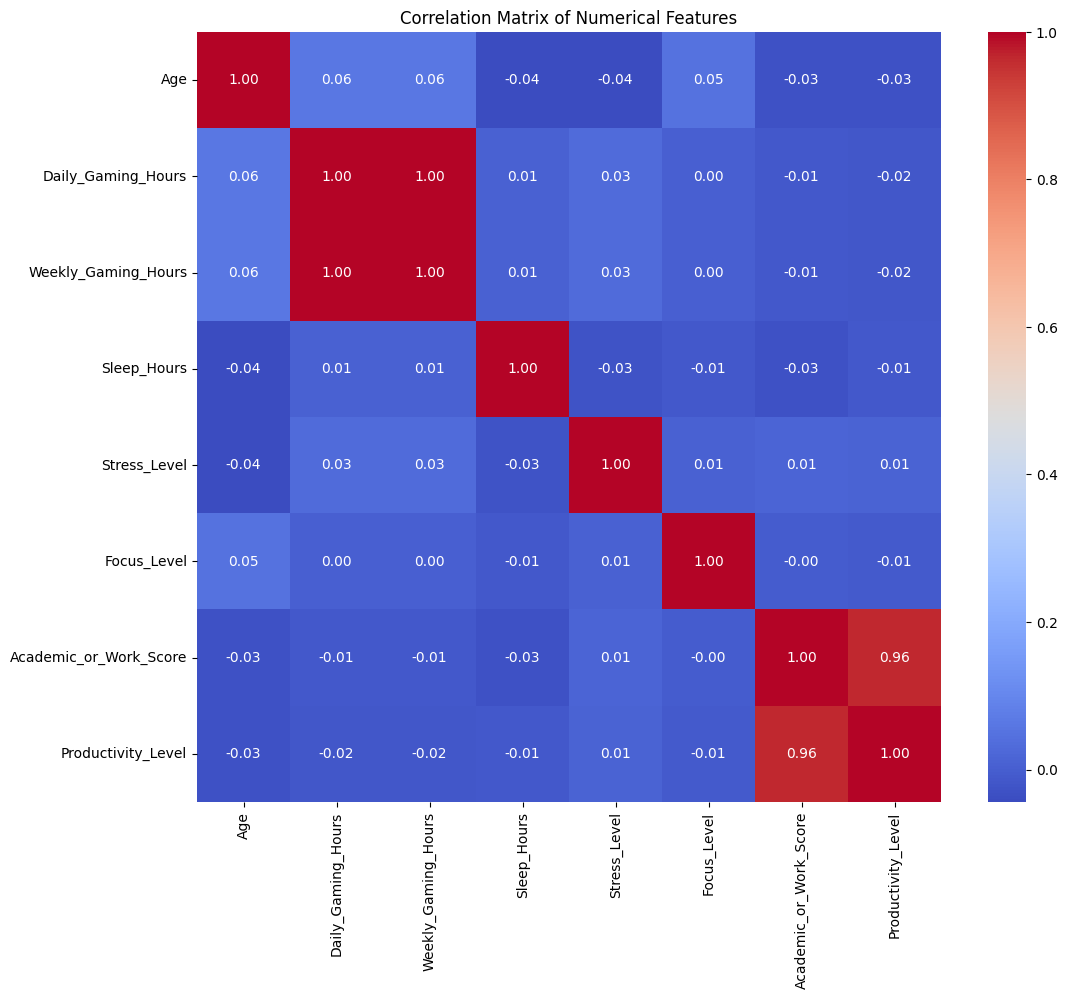

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

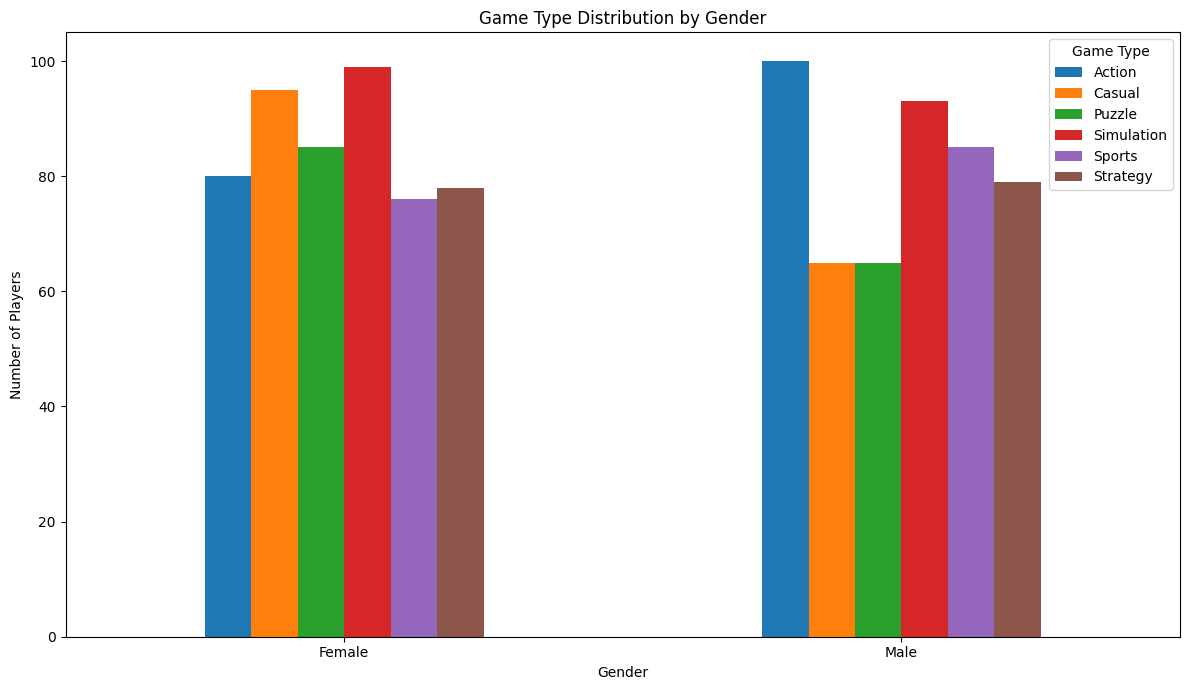

In [ ]:
gender_game_type_counts = df.groupby(['Gender', 'Game_Type']).size().unstack(fill_value=0)

gender_game_type_counts.plot(kind='bar', figsize=(12, 7))
plt.title('Game Type Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Players')
plt.xticks(rotation=0)
plt.legend(title='Game Type')
plt.tight_layout()
plt.show()

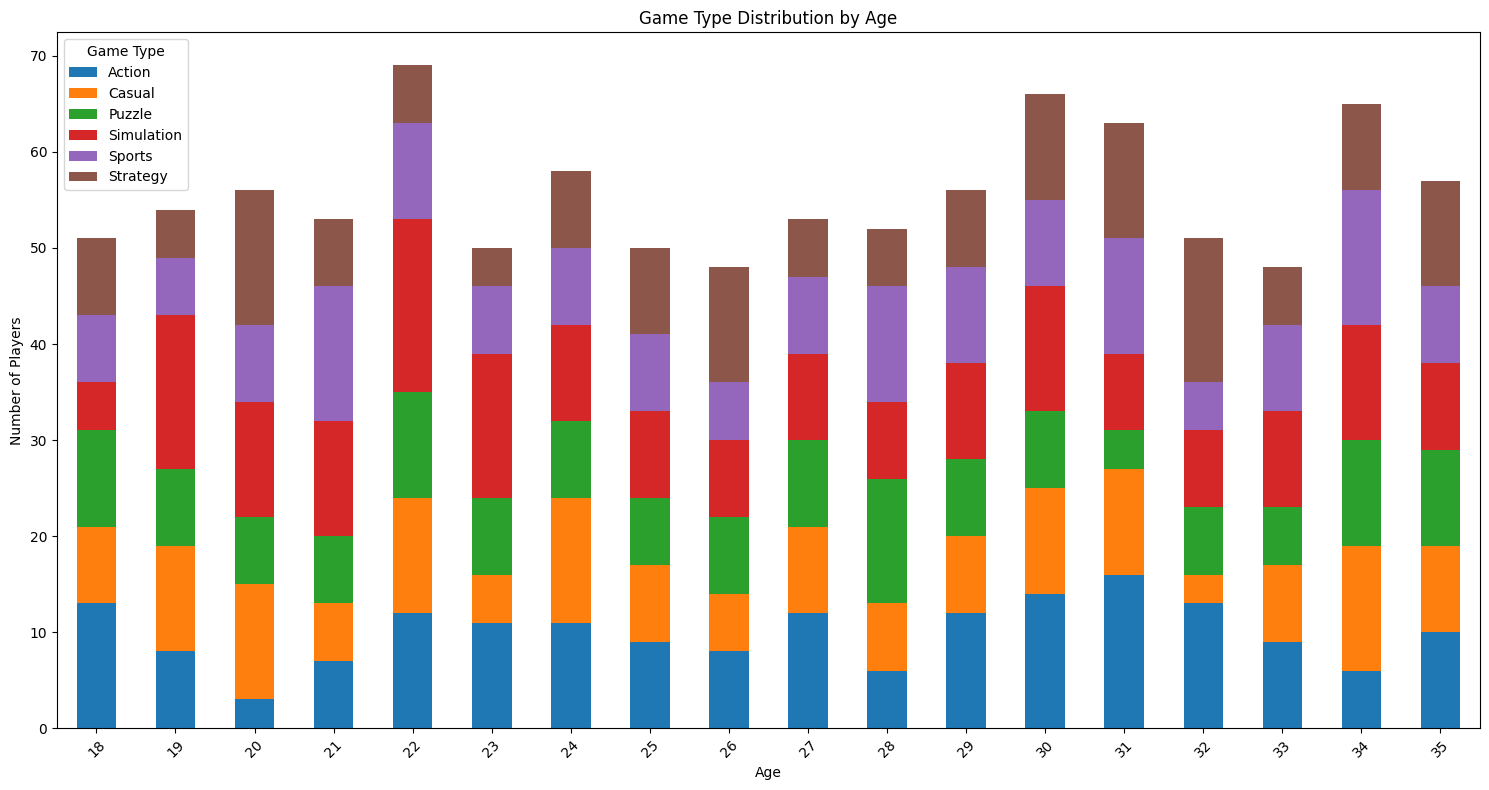

In [ ]:
age_game_type_counts = df.groupby(['Age', 'Game_Type']).size().unstack(fill_value=0)

age_game_type_counts.plot(kind='bar', figsize=(15, 8), stacked=True)
plt.title('Game Type Distribution by Age')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.legend(title='Game Type')
plt.tight_layout()
plt.show()

Relationship between Academic/ Work vs Daily Gaming Hours

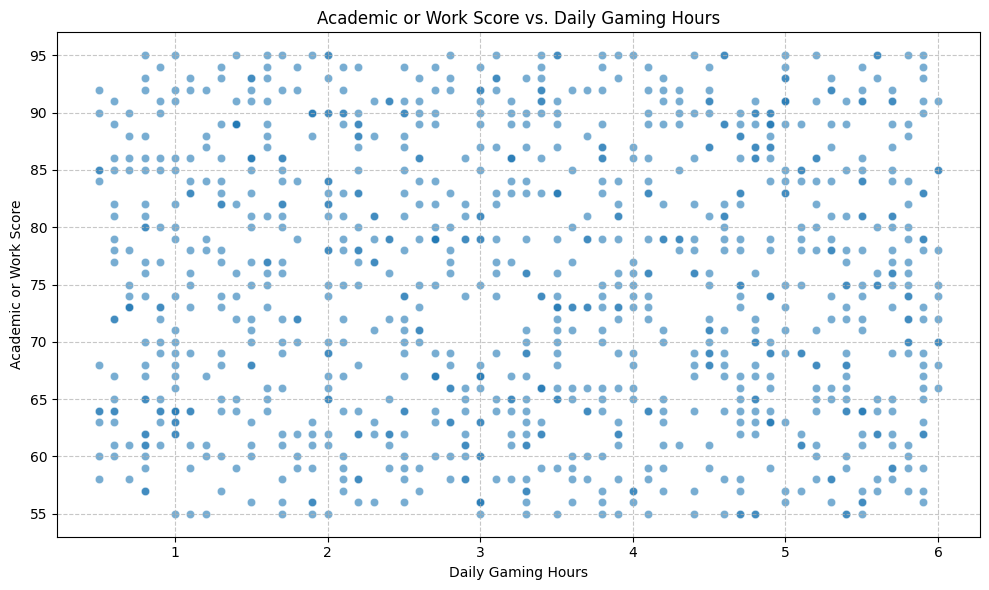

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Daily_Gaming_Hours', y='Academic_or_Work_Score', data=df, alpha=0.6)
plt.title('Academic or Work Score vs. Daily Gaming Hours')
plt.xlabel('Daily Gaming Hours')
plt.ylabel('Academic or Work Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
correlation_value = correlation_matrix.loc['Academic_or_Work_Score', 'Daily_Gaming_Hours']
print(f"Correlation between Academic_or_Work_Score and Daily_Gaming_Hours: {correlation_value:.2f}")

Correlation between Academic_or_Work_Score and Daily_Gaming_Hours: -0.01


Relationship between Academic/ Work vs Stress Level

In [ ]:
correlation_value_stress = correlation_matrix.loc['Academic_or_Work_Score', 'Stress_Level']
print(f"Correlation between Academic_or_Work_Score and Stress_Level: {correlation_value_stress:.2f}")

Correlation between Academic_or_Work_Score and Stress_Level: 0.01


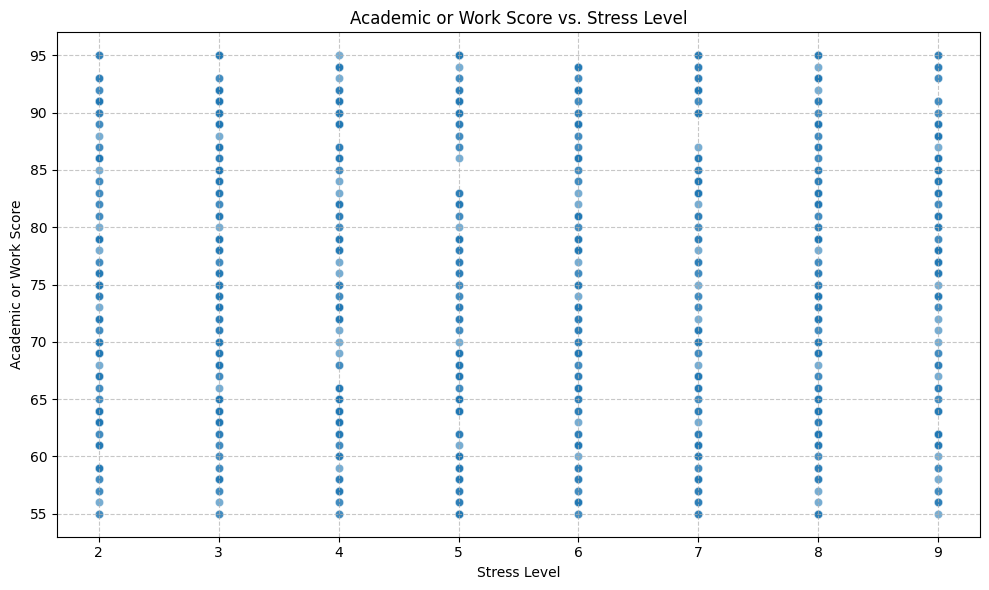

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Stress_Level', y='Academic_or_Work_Score', data=df, alpha=0.6)
plt.title('Academic or Work Score vs. Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Academic or Work Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation between Academic_or_Work_Score and Daily_Gaming_Hours:
# The calculated correlation coefficient is -0.01, indicating a very weak negative linear relationship.
# The scatter plot of 'Academic_or_Work_Score' vs 'Daily_Gaming_Hours' visually confirms this, as the data points are widely scattered with no discernible linear trend.
# This suggests that, based on this dataset, there is no significant linear impact of daily gaming hours on academic or work scores.

Relationship between Academic or Work and Weekly Gaming Hours

In [ ]:
correlation_value_weekly = correlation_matrix.loc['Academic_or_Work_Score', 'Weekly_Gaming_Hours']
print(f"Correlation between Academic_or_Work_Score and Weekly_Gaming_Hours: {correlation_value_weekly:.2f}")

Correlation between Academic_or_Work_Score and Weekly_Gaming_Hours: -0.01


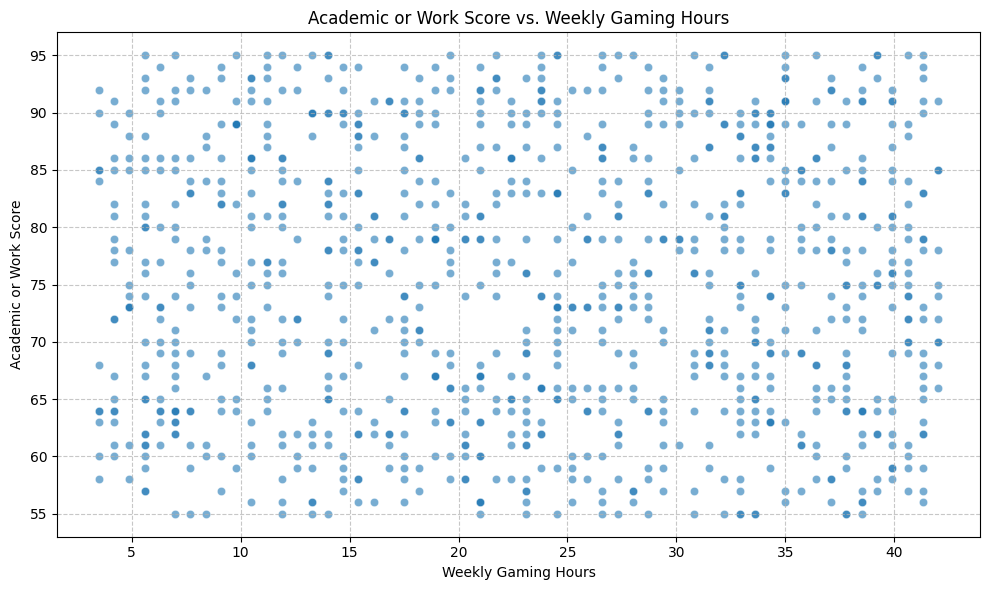

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weekly_Gaming_Hours', y='Academic_or_Work_Score', data=df, alpha=0.6)
plt.title('Academic or Work Score vs. Weekly Gaming Hours')
plt.xlabel('Weekly Gaming Hours')
plt.ylabel('Academic or Work Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Relationship between productivity and gaming hours

Correlation between Productivity_Level and Daily_Gaming_Hours: -0.02


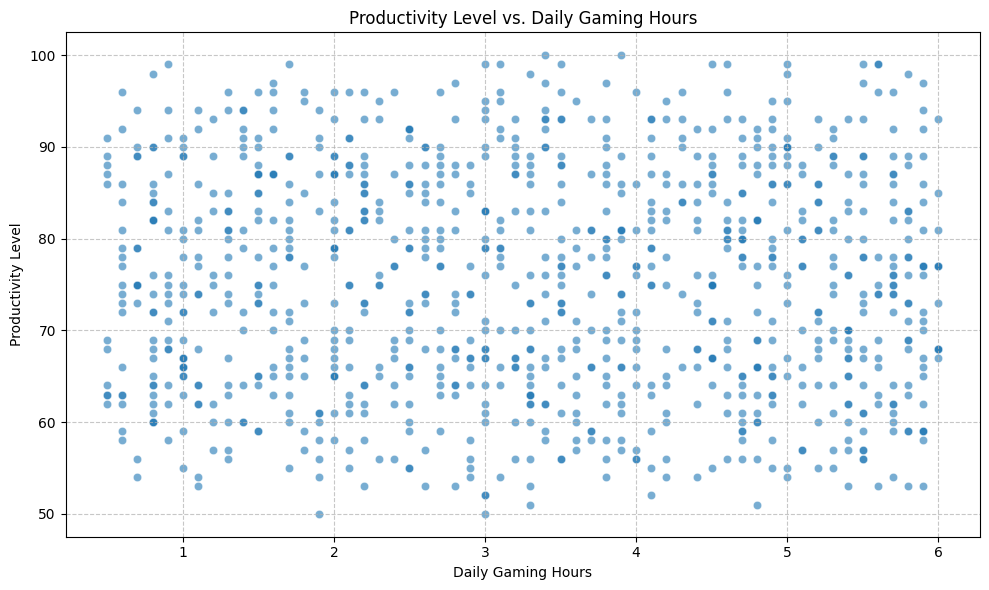

Correlation between Productivity_Level and Weekly_Gaming_Hours: -0.02


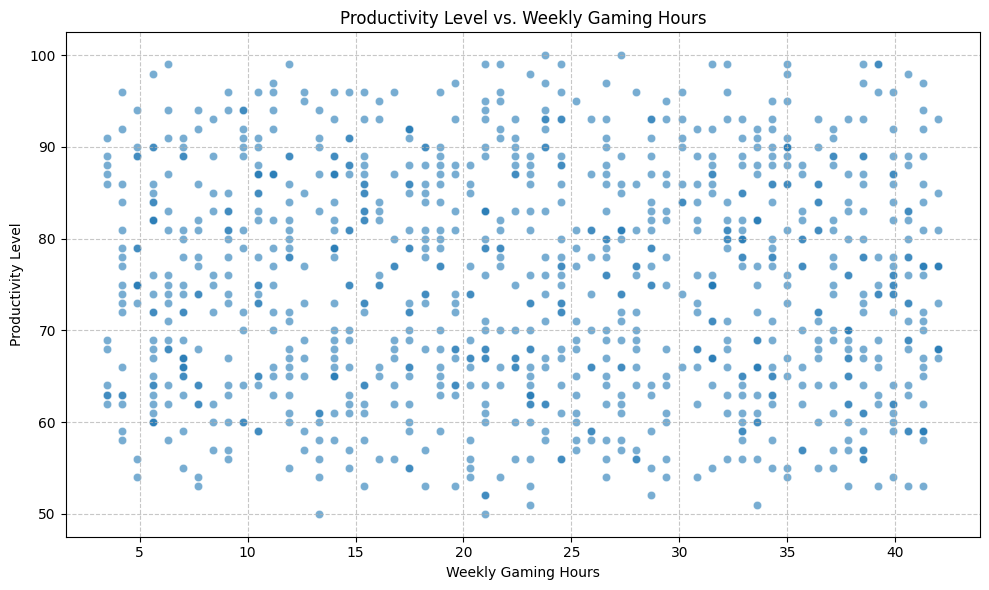

In [ ]:
# Relationship between Productivity and Daily Gaming Hours
correlation_productivity_daily = correlation_matrix.loc['Productivity_Level', 'Daily_Gaming_Hours']
print(f"Correlation between Productivity_Level and Daily_Gaming_Hours: {correlation_productivity_daily:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Daily_Gaming_Hours', y='Productivity_Level', data=df, alpha=0.6)
plt.title('Productivity Level vs. Daily Gaming Hours')
plt.xlabel('Daily Gaming Hours')
plt.ylabel('Productivity Level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Relationship between Productivity and Weekly Gaming Hours
correlation_productivity_weekly = correlation_matrix.loc['Productivity_Level', 'Weekly_Gaming_Hours']
print(f"Correlation between Productivity_Level and Weekly_Gaming_Hours: {correlation_productivity_weekly:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weekly_Gaming_Hours', y='Productivity_Level', data=df, alpha=0.6)
plt.title('Productivity Level vs. Weekly Gaming Hours')
plt.xlabel('Weekly Gaming Hours')
plt.ylabel('Productivity Level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Relationship between Sleep Hours and Gaming

Correlation between Sleep_Hours and Daily_Gaming_Hours: 0.01


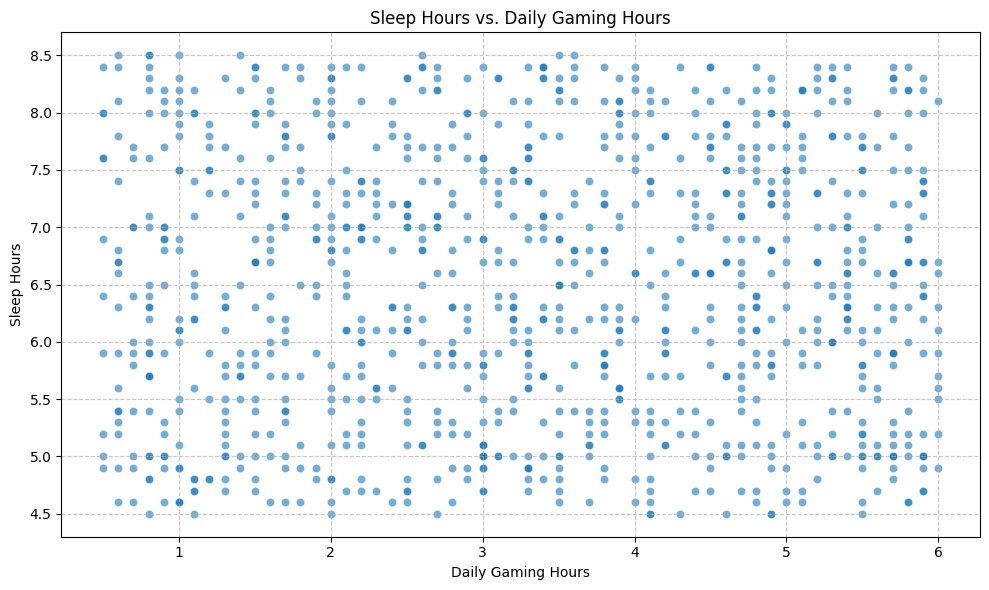

Correlation between Sleep_Hours and Weekly_Gaming_Hours: 0.01


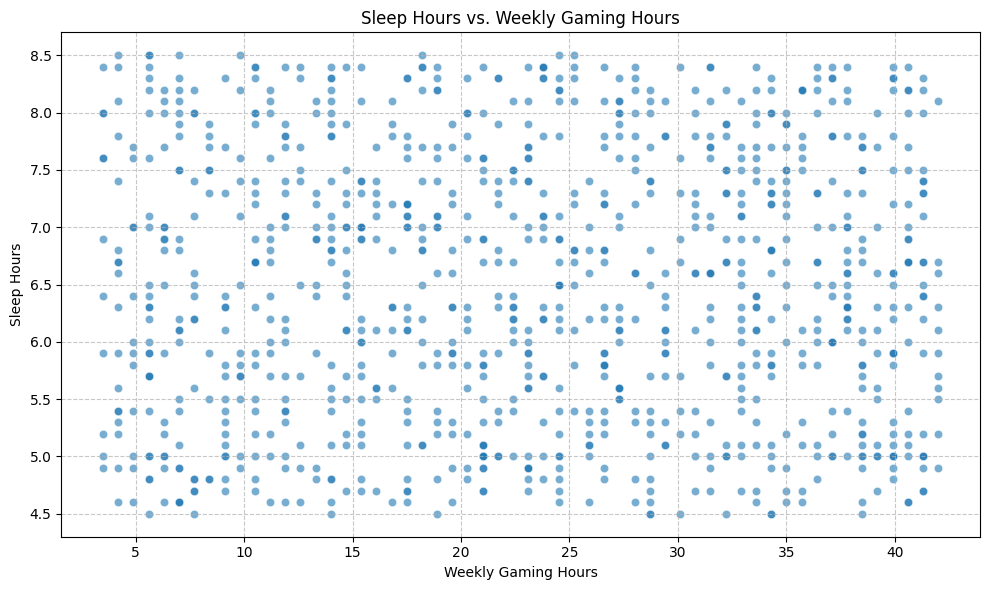

In [ ]:
# Relationship between Sleep_Hours and Daily_Gaming_Hours
correlation_sleep_daily_gaming = correlation_matrix.loc['Sleep_Hours', 'Daily_Gaming_Hours']
print(f"Correlation between Sleep_Hours and Daily_Gaming_Hours: {correlation_sleep_daily_gaming:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Daily_Gaming_Hours', y='Sleep_Hours', data=df, alpha=0.6)
plt.title('Sleep Hours vs. Daily Gaming Hours')
plt.xlabel('Daily Gaming Hours')
plt.ylabel('Sleep Hours')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Relationship between Sleep_Hours and Weekly_Gaming_Hours
correlation_sleep_weekly_gaming = correlation_matrix.loc['Sleep_Hours', 'Weekly_Gaming_Hours']
print(f"Correlation between Sleep_Hours and Weekly_Gaming_Hours: {correlation_sleep_weekly_gaming:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weekly_Gaming_Hours', y='Sleep_Hours', data=df, alpha=0.6)
plt.title('Sleep Hours vs. Weekly Gaming Hours')
plt.xlabel('Weekly Gaming Hours')
plt.ylabel('Sleep Hours')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Task
Prepare the data for machine learning from the file "Gaming_Hours_vs_Performance_1000_Rows.csv", which may include handling missing values, encoding categorical variables, scaling numerical features, and splitting data into training and testing sets.

## Data Preprocessing

### Subtask:
Prepare the data for machine learning, which may include handling missing values, encoding categorical variables, scaling numerical features, and splitting data into training and testing sets.


**Reasoning**:
The subtask requires preparing the data for machine learning. The first steps involve identifying the target variable, encoding it, separating features and target, and then splitting the dataset into training and testing sets. I will use `LabelEncoder` for the target variable and `train_test_split` for splitting the data.



# Task
Prepare the data for machine learning from the file "/content/drive/MyDrive/Colab Notebooks/Data Science Project/Gaming_Hours_vs_Performance_1000_Rows.csv", including handling missing values, encoding categorical variables, scaling numerical features, and splitting data into training and testing sets.

## Identify and Encode Target Variable

### Subtask:
Identify the target variable ('Performance_Impact') and encode it into a numerical format.


**Reasoning**:
The target variable needs to be encoded into a numerical format for machine learning models. I will use `LabelEncoder` to transform the categorical 'Performance_Impact' column.



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Define the target variable
target_variable = 'Performance_Impact'

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to the target variable
df['Performance_Impact_encoded'] = le.fit_transform(df[target_variable])

# Display the first few rows with the new encoded column
print(df[[target_variable, 'Performance_Impact_encoded']].head())

  Performance_Impact  Performance_Impact_encoded
0           Negative                           0
1            Neutral                           1
2           Positive                           2
3            Neutral                           1
4            Neutral                           1


## Separate Features and Target

### Subtask:
Separate the DataFrame into features (X) and the encoded target variable (y).


**Reasoning**:
To prepare the data for machine learning, I will separate the features (X) from the target variable (y). The instructions specify which columns to exclude from the features and which to include in the target.



In [ ]:
X = df.drop(columns=['User_ID', 'Performance_Impact', 'Performance_Impact_encoded'])
y = df['Performance_Impact_encoded']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Features (X) head:\n", X.head())
print("Target (y) head:\n", y.head())

Features (X) shape: (1000, 12)
Target (y) shape: (1000,)
Features (X) head:
    Age  Gender            Occupation Game_Type  Daily_Gaming_Hours  \
0   21    Male  Working Professional    Action                 4.0   
1   35  Female               Student    Sports                 1.0   
2   26    Male               Student    Puzzle                 2.0   
3   32    Male  Working Professional    Action                 1.0   
4   19    Male  Working Professional    Action                 2.1   

   Weekly_Gaming_Hours Primary_Gaming_Time  Sleep_Hours  Stress_Level  \
0                 28.0             Morning          4.6             6   
1                  7.0               Night          5.4             2   
2                 14.0             Morning          8.0             4   
3                  7.0               Night          4.9             7   
4                 14.7             Morning          7.0             7   

   Focus_Level  Academic_or_Work_Score  Productivity_Level  
0 

## Handle Categorical Features

### Subtask:
Convert categorical features in `X` into a numerical format using one-hot encoding.

### Reasoning:
Machine learning models typically require numerical input. The `X` DataFrame currently contains categorical columns such as 'Gender', 'Occupation', 'Game_Type', and 'Primary_Gaming_Time'. To make these suitable for modeling, I will apply one-hot encoding using `pd.get_dummies`.

**Reasoning**:
To prepare the data for machine learning, I will convert the categorical features in `X` into a numerical format using one-hot encoding. This involves identifying the object type columns and applying `pd.get_dummies` to them.



In [ ]:
X_encoded = pd.get_dummies(X, columns=['Gender', 'Occupation', 'Game_Type', 'Primary_Gaming_Time'], drop_first=True)

print("Shape of X after one-hot encoding:", X_encoded.shape)
print("First 5 rows of X after one-hot encoding:\n", X_encoded.head())

Shape of X after one-hot encoding: (1000, 17)
First 5 rows of X after one-hot encoding:
    Age  Daily_Gaming_Hours  Weekly_Gaming_Hours  Sleep_Hours  Stress_Level  \
0   21                 4.0                 28.0          4.6             6   
1   35                 1.0                  7.0          5.4             2   
2   26                 2.0                 14.0          8.0             4   
3   32                 1.0                  7.0          4.9             7   
4   19                 2.1                 14.7          7.0             7   

   Focus_Level  Academic_or_Work_Score  Productivity_Level  Gender_Male  \
0            4                      69                  66         True   
1            7                      67                  72        False   
2            8                      82                  82         True   
3            7                      71                  66         True   
4            7                      67                  63         

## Split Data into Training and Testing Sets

### Subtask:
Split the preprocessed features (`X_encoded`) and the target variable (`y`) into training and testing sets.

### Reasoning:
Splitting the data into training and testing sets is a fundamental step in machine learning. The training set will be used to train the model, while the testing set will be used to evaluate its performance on unseen data. This helps in assessing the model's generalization capability and preventing overfitting. I will use `train_test_split` from `sklearn.model_selection` with a test size of 20% and a `random_state` for reproducibility.

**Reasoning**:
Following the introduction of the data splitting subtask, I will now implement the code to split the `X_encoded` (features) and `y` (target) into training and testing sets using `train_test_split`. I will set `test_size` to 0.2 and `random_state` to 42 for consistent results, and then print the shapes of the resulting datasets to verify the split.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 17)
X_test shape: (200, 17)
y_train shape: (800,)
y_test shape: (200,)


## Scale Numerical Features

### Subtask:
Scale the numerical features in the training and testing sets.


### Reasoning:
I will scale the numerical features to ensure that all features contribute equally to the model's performance and prevent features with larger values from dominating the learning process. I will identify the numerical columns (excluding the one-hot encoded ones) from the original `X` DataFrame, then apply `StandardScaler` to `X_train` and `X_test`, preserving the column names.

**Reasoning**:
Following the instructions, I will now implement the code to scale the numerical features. First, I'll identify the numerical columns from the original `X` DataFrame that were not subjected to one-hot encoding. Then, I will initialize `StandardScaler`, fit it to the training data, and transform both the training and testing sets, ensuring column names are maintained for clarity and further analysis.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns from the original X DataFrame that were not one-hot encoded
numerical_cols_to_scale = X.select_dtypes(include=['int64', 'float64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("X_train after scaling:")
print(X_train[numerical_cols_to_scale].head())
print("\nX_test after scaling:")
print(X_test[numerical_cols_to_scale].head())

X_train after scaling:
          Age  Daily_Gaming_Hours  Weekly_Gaming_Hours  Sleep_Hours  \
29  -0.509533            0.771363             0.771363    -1.187671   
535  0.826321           -1.390398            -1.390398     0.805865   
695  1.398829           -1.081575            -1.081575    -0.667618   
557  1.017157            0.956657             0.956657    -0.580942   
836  1.589666            0.709598             0.709598    -1.534373   

     Stress_Level  Focus_Level  Academic_or_Work_Score  Productivity_Level  
29       0.231000     0.454350               -0.614308           -0.609121  
535     -1.073469    -0.041530                1.521673            1.368410  
695     -1.073469    -1.529171               -0.870626           -1.021106  
557     -1.073469     1.446111               -0.101673            0.132453  
836     -1.073469     1.446111               -0.016233           -0.032341  

X_test after scaling:
          Age  Daily_Gaming_Hours  Weekly_Gaming_Hours  Sleep_Hou

## Summary:

### Data Analysis Key Findings

*   **Target Variable Encoding**: The 'Performance_Impact' variable was successfully encoded into a numerical format, creating a new column 'Performance_Impact_encoded'. 'Negative' was encoded as 0, 'Neutral' as 1, and 'Positive' as 2.
*   **Feature and Target Separation**: The dataset was successfully separated into features (X) and the encoded target (y). The `User_ID`, original `Performance_Impact`, and `Performance_Impact_encoded` columns were excluded from the features.
*   **Categorical Feature Encoding**: Categorical features ('Gender', 'Occupation', 'Game_Type', 'Primary_Gaming_Time') were transformed into numerical format using one-hot encoding with `drop_first=True`. This process expanded the feature set from 12 original features to 17 after encoding.
*   **Data Splitting**: The preprocessed data was split into training and testing sets, with 80% (800 samples) allocated for training and 20% (200 samples) for testing, ensuring readiness for model evaluation.
*   **Numerical Feature Scaling**: Numerical features within both the training and testing sets were scaled using `StandardScaler`. This standardization ensures that all numerical features contribute equally to the machine learning model without being dominated by features with larger initial values.

### Insights or Next Steps

*   The data is now fully preprocessed and ready for machine learning model training and evaluation, including classification tasks based on the encoded 'Performance_Impact'.
*   Further analysis could involve exploring feature importance after model training to understand which gaming-related factors most significantly influence performance impact.


In [ ]:
# Re-run all necessary data preprocessing steps to ensure X_train, y_train, X_test, y_test are defined

# 1. Identify and Encode Target Variable (from a07ed5bf)
from sklearn.preprocessing import LabelEncoder

target_variable = 'Performance_Impact'
le = LabelEncoder()
df['Performance_Impact_encoded'] = le.fit_transform(df[target_variable])

# 2. Separate Features and Target (from 0206b688)
X = df.drop(columns=['User_ID', 'Performance_Impact', 'Performance_Impact_encoded'])
y = df['Performance_Impact_encoded']

# 3. Handle Categorical Features (from 86064de3)
# Assuming pandas is already imported from an earlier cell
X_encoded = pd.get_dummies(X, columns=['Gender', 'Occupation', 'Game_Type', 'Primary_Gaming_Time'], drop_first=True)

# 4. Split Data into Training and Testing Sets (from f80bdb00)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 5. Scale Numerical Features (from 72674c7b)
from sklearn.preprocessing import StandardScaler

numerical_cols_to_scale = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Data preprocessing steps re-executed. X_train, X_test, y_train, y_test are now defined.")

Data preprocessing steps re-executed. X_train, X_test, y_train, y_test are now defined.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_reg_model.fit(X_train, y_train)

print("Logistic Regression Model trained successfully.")

Logistic Regression Model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

print("Predictions made on the test set.")

Predictions made on the test set.


In [ ]:
# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.88        25
           1       0.94      0.97      0.96       149
           2       0.91      0.81      0.86        26

    accuracy                           0.94       200
   macro avg       0.92      0.87      0.90       200
weighted avg       0.93      0.94      0.93       200


Confusion Matrix:
[[ 21   4   0]
 [  2 145   2]
 [  0   5  21]]


The classification report provides a detailed breakdown of the model's performance for each class.
For precision,it measures the proportion of correctly predicted positive observations to the total predicted positive observations.  A high precision means a low positive rate.
For class 0 (Negative), 91% of the predictions were correct.
For class 1 (Neutral), 94% of the predictions were correct.
For class 2 (Positive), 91% of the predictions were correct.

Recall: For each class, recall measures the proportion of correctly predicted positive observations to the all observations in actual class. A high recall means a low false negative rate.

For class 0 (Negative), the model correctly identified 84% of all actual 'Negative' cases.
For class 1 (Neutral), the model correctly identified 97% of all actual 'Neutral' cases.
For class 2 (Positive), the model correctly identified 81% of all actual 'Positive' cases.
F1-score: The F1-score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall. A higher F1-score indicates a better balance.

Class 0 (Negative): 0.88
Class 1 (Neutral): 0.96
Class 2 (Positive): 0.86
Support: The number of actual occurrences of each class in the specified dataset (in this case, the test set).

There are 25 'Negative' cases, 149 'Neutral' cases, and 26 'Positive' cases in the test set.
Accuracy: The overall accuracy of the model, which is the proportion of total correct predictions across all classes. Your model has an overall accuracy of 94%.

Macro Avg: The average of precision, recall, and F1-score across all classes, without considering class imbalance.

Weighted Avg: The average of precision, recall, and F1-score across all classes, weighted by the support of each class. This is useful when you have imbalanced classes.

In summary **bold text**, your Logistic Regression model performs quite well, especially for the 'Neutral' class (class 1) with high precision and recall. Performance for 'Negative' (class 0) and 'Positive' (class 2) is also strong, though slightly lower in recall compared to 'Neutral'. The overall accuracy of 94% is very good.